## Modelling (Customer Churn Prediction)

### Load Engineered Features

In [46]:
# Import Liberaries and Load Engineered Features
import pandas as pd
import numpy as np
from pathlib import Path

X = pd.read_csv(Path(r"D:\Datasets\Research\Customer Churn\Telco Customer Churn\data\processed\X_features.csv"))
y = pd.read_csv(Path(r"D:\Datasets\Research\Customer Churn\Telco Customer Churn\data\processed\y_target.csv"))

X.shape, y.shape

((7032, 29), (7032, 1))

### Train/Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5625, 29)
Test shape: (1407, 29)


### Feature Scaling (for Logistic Regression only)

Random Forest does not need scaling.

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### MODEL 1 - Logistic Regression (Baseline)

In [49]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:,1]

c:\Users\natha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### MODEL 2 - Random Forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    # class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

c:\Users\natha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


### Evaluation Metrics

In [51]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

#### Logistic Regression

In [52]:
log_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_proba_log)
}

#### Random Forest

In [53]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
}

### Results Table

In [54]:
results_df = pd.DataFrame([log_results, rf_results])
results_df

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.792466,0.632258,0.524064,0.834736
1,Random Forest,0.788913,0.626230,0.510695,0.824448


### Confusion Matrix

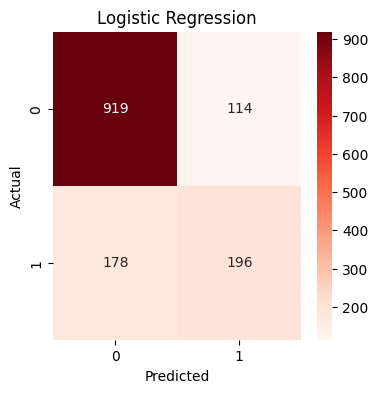

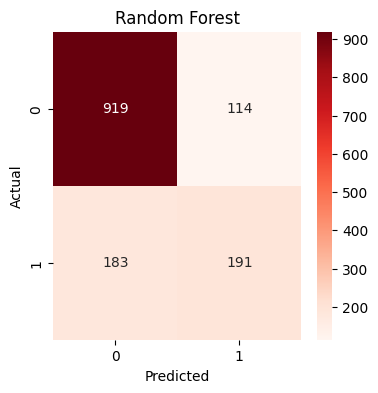

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

plot_conf_matrix(y_test, y_pred_log, "Logistic Regression")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest")

## Feature Importance

### Random Forest Feature Importance

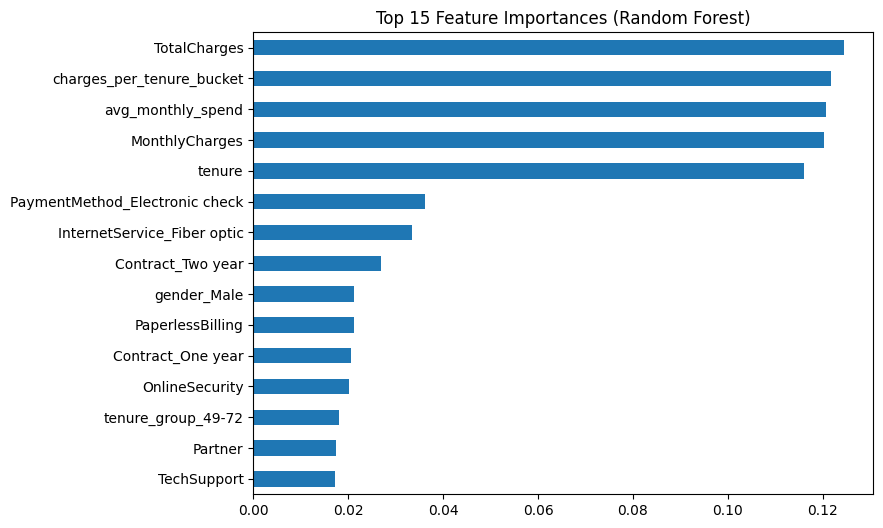

In [56]:
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
). sort_values(ascending=False)

top_features = feature_importances.head(15)

plt.figure(figsize=(8,6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

### Logistic Regression Coefficients

In [57]:
coef_df = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

coef_df.head(10)

InternetService_Fiber optic       0.678655
tenure_group_49-72                0.272722
StreamingTV                       0.232856
TotalCharges                      0.224036
MultipleLines                     0.223869
StreamingMovies                   0.214366
PaymentMethod_Electronic check    0.175928
avg_monthly_spend                 0.169785
PaperlessBilling                  0.144098
SeniorCitizen                     0.076160
dtype: float64

In [58]:
import numpy as np
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred_adj = (y_proba_rf >= t).astype(int)
    print(
        f"Threshold {t:.2f} | Recall: {recall_score(y_test, y_pred_adj):.3f} | Precision: {precision_score(y_test, y_pred_adj):.3f}"
    )


Threshold 0.10 | Recall: 0.936 | Precision: 0.383
Threshold 0.15 | Recall: 0.901 | Precision: 0.422
Threshold 0.20 | Recall: 0.842 | Precision: 0.447
Threshold 0.25 | Recall: 0.805 | Precision: 0.486
Threshold 0.30 | Recall: 0.765 | Precision: 0.523
Threshold 0.35 | Recall: 0.693 | Precision: 0.559
Threshold 0.40 | Recall: 0.631 | Precision: 0.580
Threshold 0.45 | Recall: 0.567 | Precision: 0.601
Threshold 0.50 | Recall: 0.511 | Precision: 0.626
Threshold 0.55 | Recall: 0.436 | Precision: 0.652
Threshold 0.60 | Recall: 0.364 | Precision: 0.663
Threshold 0.65 | Recall: 0.321 | Precision: 0.702
Threshold 0.70 | Recall: 0.259 | Precision: 0.724
Threshold 0.75 | Recall: 0.198 | Precision: 0.747
Threshold 0.80 | Recall: 0.144 | Precision: 0.750
Threshold 0.85 | Recall: 0.099 | Precision: 0.822
